In [2]:
# 셀 1: 패키지 설치
!pip install monai==1.3.1 transformers==4.41.0 numpy==1.26.4 nibabel==5.2.1 \
    SimpleITK==2.3.1 einops==0.8.0 peft==0.8.2 safetensors==0.4.3 \
    accelerate deep-translator sentencepiece matplotlib pandas seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 M

In [1]:
# 셀 2: 레포 클론
!git clone https://github.com/yuji4/MedSeg3D-KO.git
%cd MedSeg3D-KO

Cloning into 'MedSeg3D-KO'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 173 (delta 70), reused 143 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 30.81 MiB | 32.80 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/MedSeg3D-KO


In [2]:
# 셀 3: 임포트 및 한국어 폰트
import sys, os
import numpy as np
import nibabel as nib
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from deep_translator import GoogleTranslator

sys.path.insert(0, '/content/MedSeg3D-KO')

!apt-get install -y fonts-nanum -q
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("완료")

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (68.5 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
완료


In [3]:
# 셀 4: GPU 확인
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [4]:
# 셀 5: 모델 로드
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "GoodBaiBai88/M3D-LaMed-Phi-3-4B"
tokenizer = AutoTokenizer.from_pretrained(
    model_name, model_max_length=512, padding_side="right",
    use_fast=False, trust_remote_code=True
)
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.bfloat16,
    device_map='auto', trust_remote_code=True
)
model.eval()
print("모델 로드 성공")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.blocks.patchembedding PatchEmbeddingBlock.__init__:pos_embed: Argument `pos_embed` has been deprecated since version 1.2. It will be removed in version 1.4. please use `proj_type` instead.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.vit ViT.__init__:pos_embed: Argument `pos_embed` has been deprecated since version 1.2. It will be removed in version 1.4. please use `proj_type` instead.
  warn_deprecated(argname, msg, warning_category)


build_sam_vit_3d...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

모델 로드 성공


In [5]:
# 셀 6: 파이프라인 및 유틸 초기화
from src.inference.segmentation import SegmentationPipeline, _build_english_prompt
from src.inference.model_loader import PROJ_OUT_NUM
from src.translation.medical_terms import TERM_KO

pipeline = SegmentationPipeline()
pipeline.model = model
pipeline.tokenizer = tokenizer
pipeline._device = next(model.parameters()).device

def dice_score(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = (pred & gt).sum()
    if pred.sum() + gt.sum() == 0:
        return 1.0
    return 2 * intersection / (pred.sum() + gt.sum())

def run_inference(image_pt, prompt, threshold=0.5):
    full_prompt = "<im_patch>" * PROJ_OUT_NUM + prompt
    input_ids = tokenizer(full_prompt, return_tensors="pt")["input_ids"].to(pipeline._device)
    dtype = next(model.parameters()).dtype
    image_pt = image_pt.to(dtype=dtype, device=pipeline._device)
    with torch.no_grad():
        generation, seg_logit = model.generate(
            image_pt, input_ids, seg_enable=True,
            max_new_tokens=256, do_sample=False
        )
    text = tokenizer.decode(generation[0], skip_special_tokens=True)
    mask = (torch.sigmoid(seg_logit) > threshold).squeeze().cpu().numpy().astype(bool)
    return mask, text

print("파이프라인 준비 완료")

파이프라인 준비 완료


In [6]:
# 셀 7: 데이터 로드
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = '/content/drive/MyDrive/Task07_Pancreas_Partially'
cases = ['pancreas_001', 'pancreas_004', 'pancreas_005', 'pancreas_006', 'pancreas_010']

def load_case(case):
    img = nib.load(f'{DATA_ROOT}/imagesTr/{case}.nii/{case}.nii')
    gt  = nib.load(f'{DATA_ROOT}/labelsTr/{case}.nii/{case}.nii')
    arr = img.get_fdata().astype(np.float32).transpose(2, 1, 0)
    gt_arr = (gt.get_fdata().astype(np.uint8).transpose(2, 1, 0) == 1)
    return arr, gt_arr

arr, gt = load_case('pancreas_001')
print("CT shape:", arr.shape, "| GT 복셀:", gt.sum())

Mounted at /content/drive
CT shape: (110, 512, 512) | GT 복셀: 39557


In [9]:
# 셀 8: 실험 A - Layer 1 의도 분류 Robustness
# paraphrase set으로 다양한 한국어 표현에서 의도 분류 강건성 평가

SEG_KEYWORDS    = ["분할", "세그", "찾아", "마스크", "보여", "표시", "구분", "따줘", "떼줘", "잘라", "분리", "경계", "만들어"]
VQA_KEYWORDS    = ["어때", "상태", "이상", "정상", "크기", "문제", "왜", "있어", "있나", "보이니", "병변", "종양"]
REPORT_KEYWORDS = ["소견", "리포트", "보고서", "findings", "report", "진단", "판독", "정리"]
REG_KEYWORDS    = ["설명", "묘사", "뭔지", "알려줘", "역할", "기능"]

def classify_intent(q: str) -> str:
    q = q.lower()
    if any(k in q for k in REPORT_KEYWORDS):
        return "Report"
    if any(k in q for k in SEG_KEYWORDS):
        return "Segmentation"
    if any(k in q for k in REG_KEYWORDS):
        return "REG"
    if any(k in q for k in VQA_KEYWORDS):
        return "VQA"
    return "VQA"

test_queries = [
    # Segmentation (15개)
    ("췌장 분할해줘",           "Segmentation"),
    ("췌장만 분리해줘",         "Segmentation"),
    ("췌장 영역 표시해줘",      "Segmentation"),
    ("췌장 마스크 만들어줘",    "Segmentation"),
    ("췌장 경계 보여줘",        "Segmentation"),
    ("췌장 따줘",               "Segmentation"),
    ("췌장 떼줘",               "Segmentation"),
    ("췌장 세그멘테이션해줘",   "Segmentation"),
    ("간 분할해줘",             "Segmentation"),
    ("간 마스크 보여줘",        "Segmentation"),
    ("신장 찾아줘",             "Segmentation"),
    ("비장 표시해줘",           "Segmentation"),
    ("췌장만 보고싶어",         "Segmentation"),
    ("간 구분해줘",             "Segmentation"),
    ("신장 경계 만들어줘",      "Segmentation"),

    # VQA (15개)
    ("췌장 상태 어때?",         "VQA"),
    ("종양 있어?",              "VQA"),
    ("병변 보이니?",            "VQA"),
    ("이상 소견 있나?",         "VQA"),
    ("간에 이상이 있어?",       "VQA"),
    ("이 CT 정상이야?",         "VQA"),
    ("신장 크기 정상이야?",     "VQA"),
    ("간이 왜 이렇게 커?",      "VQA"),
    ("비장에 문제있어?",        "VQA"),
    ("췌장이 정상으로 보여?",   "VQA"),
    ("뭔가 이상한 점 있어?",    "VQA"),
    ("간 종양 있어?",           "VQA"),
    ("췌장 염증 있어?",         "VQA"),
    ("간이 커 보이는데?",       "VQA"),
    ("신장 대칭이야?",          "VQA"),

    # Report (10개)
    ("소견서 써줘",             "Report"),
    ("영상 판독해줘",           "Report"),
    ("리포트 작성해줘",         "Report"),
    ("진단 결과 정리해줘",      "Report"),
    ("CT 보고서 만들어줘",      "Report"),
    ("전체 소견 작성해",        "Report"),
    ("report 생성해줘",         "Report"),
    ("findings 알려줘",         "Report"),
    ("의료 소견 작성해줘",      "Report"),
    ("이 영상 판독 결과 써줘",  "Report"),

    # REG (10개)
    ("췌장이 뭔지 설명해줘",    "REG"),
    ("간 기능 알려줘",          "REG"),
    ("이 장기 묘사해줘",        "REG"),
    ("신장이 어떤 장기야?",     "REG"),
    ("비장 설명해줘",           "REG"),
    ("췌장 역할이 뭐야?",       "REG"),
    ("이 부위 뭔지 알려줘",     "REG"),
    ("간이 어떤 장기인지 설명", "REG"),
    ("신장 묘사해줘",           "REG"),
    ("췌장에 대해 알려줘",      "REG"),
]

correct = 0
results_a = []
for query, true_label in test_queries:
    predicted = classify_intent(query)
    is_correct = predicted == true_label
    if is_correct:
        correct += 1
    results_a.append({"질문": query, "정답": true_label, "예측": predicted, "correct": is_correct})

df_a = pd.DataFrame(results_a)
accuracy = correct / len(test_queries)
print(f"정확도: {accuracy:.4f} ({correct}/{len(test_queries)})")
print("\n틀린 케이스:")
wrong = df_a[~df_a["correct"]]
print(wrong[["질문", "정답", "예측"]].to_string(index=False) if len(wrong) > 0 else "없음")

정확도: 0.9200 (46/50)

틀린 케이스:
          질문           정답           예측
    췌장만 보고싶어 Segmentation          VQA
   이상 소견 있나?          VQA       Report
췌장이 정상으로 보여?          VQA Segmentation
 신장이 어떤 장기야?          REG          VQA


              precision    recall  f1-score   support

Segmentation       1.00      0.90      0.95        10
         VQA       0.91      1.00      0.95        10
      Report       0.93      0.93      0.93        15
         REG       0.87      0.87      0.87        15

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50



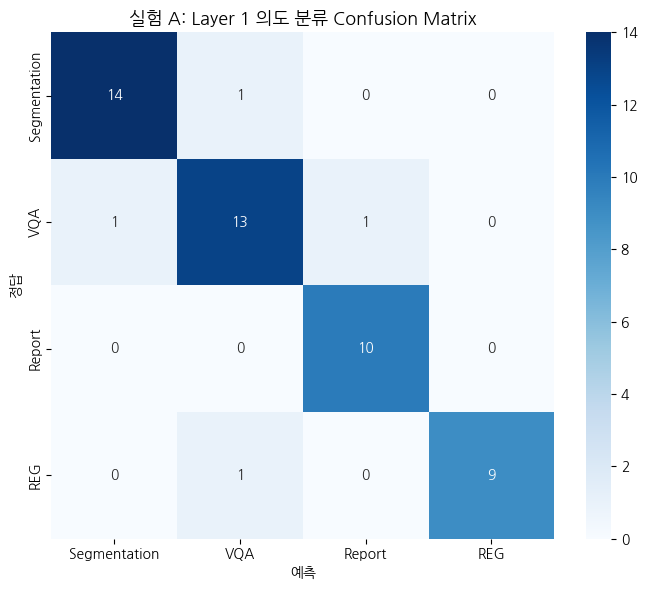

In [10]:
# 셀 9: 실험 A 시각화

y_true = [r["정답"] for r in results_a]
y_pred = [r["예측"] for r in results_a]
labels = ["Segmentation", "VQA", "Report", "REG"]

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("실험 A: Layer 1 의도 분류 Confusion Matrix", fontsize=13)
ax.set_ylabel("정답")
ax.set_xlabel("예측")
plt.tight_layout()
plt.savefig("exp_A_confusion.png", dpi=150)
plt.show()

In [11]:
# 셀 10: 실험 C - Cross-task Template 검증
# Layer 3 필요성: 잘못된 태스크 템플릿 사용 시 성능 저하

arr, gt_pancreas = load_case('pancreas_001')
preprocessed, _ = pipeline._prepare_image_pt(arr)

task_templates = {
    "Seg":    "Can you segment the pancreas in this image? Please output the mask.",
    "VQA":    "What is the condition of the pancreas in this image?",
    "Report": "Can you provide a caption consists of findings for this medical image?",
}

cross_results = {}
print("=== 실험 C: Cross-task Template ===\n")

for applied_task, applied_template in task_templates.items():
    try:
        mask, text = run_inference(preprocessed, applied_template)
        mask_full = pipeline._resize_mask(mask, arr.shape)
        dice = dice_score(mask_full, gt_pancreas)
        cross_results[applied_task] = {"dice": dice, "text": text[:60]}
        print(f"Seg질문 + {applied_task}템플릿: Dice={dice:.4f}")
        print(f"  응답: {text[:60]}\n")
    except Exception as e:
        print(f"{applied_task}: 오류 - {e}")
        cross_results[applied_task] = {"dice": 0.0, "text": "error"}

=== 실험 C: Cross-task Template ===



You are not running the flash-attention implementation, expect numerical differences.


Seg질문 + Seg템플릿: Dice=0.5037
  응답: The segmentation reveals  [SEG] .

Seg질문 + VQA템플릿: Dice=0.0000
  응답: Atrophic pancreas with calcification.

Seg질문 + Report템플릿: Dice=0.0000
  응답: Numerous liver lesions with peripheral nodular enhancement o



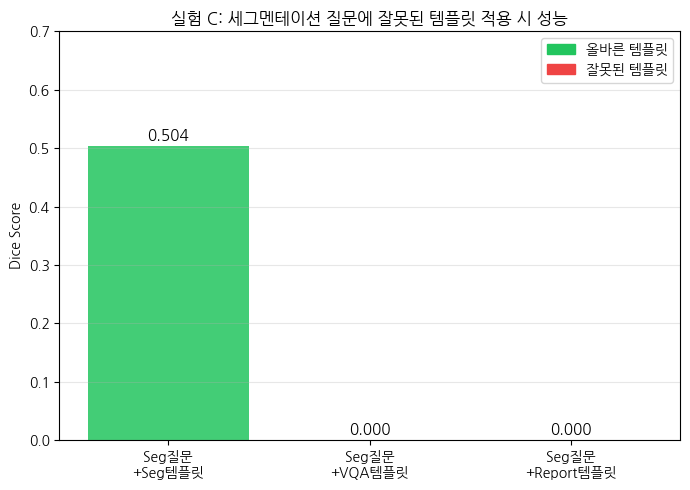

In [12]:
# 셀 11: 실험 C 시각화

labels_c = list(cross_results.keys())
dices_c  = [cross_results[k]["dice"] for k in labels_c]
colors_c = ['#22c55e' if k == 'Seg' else '#ef4444' for k in labels_c]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [f"Seg질문\n+{k}템플릿" for k in labels_c],
    dices_c, color=colors_c, alpha=0.85
)
ax.set_ylabel("Dice Score")
ax.set_title("실험 C: 세그멘테이션 질문에 잘못된 템플릿 적용 시 성능", fontsize=12)
ax.set_ylim(0, 0.7)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#22c55e', label='올바른 템플릿'),
    Patch(color='#ef4444', label='잘못된 템플릿'),
])
for bar, d in zip(bars, dices_c):
    ax.text(bar.get_x() + bar.get_width()/2, d + 0.01,
            f'{d:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("exp_C_cross_task.png", dpi=150)
plt.show()

In [13]:
# 셀 12: 실험 D - Ablation Study
# 각 계층 제거 시 성능 변화

def full_pipeline(q):
    """Full: L1 + L2 + L3"""
    return _build_english_prompt(q)

def remove_layer1(q):
    """L1 제거: 의도 분류 없이 랜덤 템플릿"""
    import random
    templates = [
        "Can you provide a caption consists of findings for this medical image?",
        "What is the condition of the pancreas in this image?",
        "Can you segment the pancreas in this image? Please output the mask.",
    ]
    return random.choice(templates)

def remove_layer2(q):
    """L2 제거: 엔티티 정규화 없이 일반 번역"""
    try:
        return GoogleTranslator(source='ko', target='en').translate(q)
    except:
        return q

def remove_layer3(q):
    """L3 제거: 엔티티 정규화만, 템플릿 없이"""
    result = q
    for en, ko in TERM_KO.items():
        result = result.replace(ko, en)
    return "pancreas" if "pancreas" in result else result

ablation_settings = {
    "Full (L1+L2+L3)":      full_pipeline,
    "-Layer1 (랜덤템플릿)": remove_layer1,
    "-Layer2 (정규화제거)": remove_layer2,
    "-Layer3 (템플릿제거)": remove_layer3,
}

question_ko = "췌장을 분할해줘"
exp_d_results = {name: [] for name in ablation_settings}

for case in cases:
    print(f"\n=== {case} ===")
    arr, gt_pancreas = load_case(case)
    preprocessed, _ = pipeline._prepare_image_pt(arr)

    for name, method in ablation_settings.items():
        try:
            prompt = method(question_ko)
            mask, text = run_inference(preprocessed, prompt)
            mask_full = pipeline._resize_mask(mask, arr.shape)
            dice = dice_score(mask_full, gt_pancreas)
            exp_d_results[name].append(dice)
            print(f"  {name}: Dice={dice:.4f} | {prompt[:50]}")
        except Exception as e:
            print(f"  {name}: 오류 - {e}")
            exp_d_results[name].append(0.0)

print("\n=== 실험 D 결과 ===")
for name, scores in exp_d_results.items():
    print(f"{name}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


=== pancreas_001 ===
  Full (L1+L2+L3): Dice=0.5037 | Can you segment the pancreas in this image? Please
  -Layer1 (랜덤템플릿): Dice=0.0000 | What is the condition of the pancreas in this imag
  -Layer2 (정규화제거): Dice=0.0000 | Split the pancreas
  -Layer3 (템플릿제거): 오류 - torch.cat(): expected a non-empty list of Tensors

=== pancreas_004 ===
  Full (L1+L2+L3): Dice=0.5417 | Can you segment the pancreas in this image? Please
  -Layer1 (랜덤템플릿): Dice=0.5417 | Can you segment the pancreas in this image? Please
  -Layer2 (정규화제거): Dice=0.0000 | Split the pancreas
  -Layer3 (템플릿제거): 오류 - torch.cat(): expected a non-empty list of Tensors

=== pancreas_005 ===
  Full (L1+L2+L3): Dice=0.6109 | Can you segment the pancreas in this image? Please
  -Layer1 (랜덤템플릿): Dice=0.0000 | What is the condition of the pancreas in this imag
  -Layer2 (정규화제거): Dice=0.0000 | Split the pancreas
  -Layer3 (템플릿제거): 오류 - torch.cat(): expected a non-empty list of Tensors

=== pancreas_006 ===
  Full (L1+L2+L3): Dice=0.5382

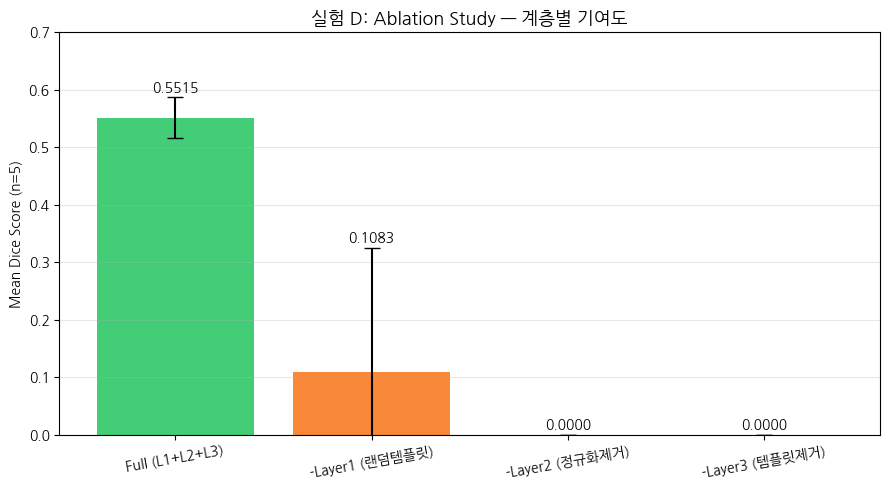

In [14]:
# 셀 13: 실험 D 시각화

names_d  = list(exp_d_results.keys())
means_d  = [np.mean(v) for v in exp_d_results.values()]
stds_d   = [np.std(v)  for v in exp_d_results.values()]
colors_d = ['#22c55e', '#f97316', '#ef4444', '#f97316']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names_d, means_d, yerr=stds_d, capsize=6,
              color=colors_d, alpha=0.85)
ax.set_ylabel("Mean Dice Score (n=5)")
ax.set_title("실험 D: Ablation Study — 계층별 기여도", fontsize=13)
ax.set_ylim(0, 0.7)
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', alpha=0.3)

for bar, m, s in zip(bars, means_d, stds_d):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.01,
            f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("exp_D_ablation.png", dpi=150)
plt.show()

In [15]:
# 셀 14: 전체 결과 종합 테이블

print("=" * 60)
print("실험 A: Layer 1 의도 분류 Robustness")
print("=" * 60)
print(f"정확도: {accuracy:.4f} ({correct}/{len(test_queries)})")
print(classification_report(y_true, y_pred, target_names=labels))

print("=" * 60)
print("실험 B: Layer 2 엔티티 정규화 (기존 결과 재활용)")
print("=" * 60)
print(pd.DataFrame({
    "방법":  ["한국어직접", "일반번역", "의료사전(L2)", "Hybrid(Full)"],
    "Dice": [0.0000, 0.0000, 0.5457, 0.5515],
    "비고":  ["L2 없음", "L2 없음", "L2만", "L1+L2+L3"],
}).to_string(index=False))

print("\n" + "=" * 60)
print("실험 C: Layer 3 Task Mismatch")
print("=" * 60)
for k, v in cross_results.items():
    print(f"  Seg질문 + {k}템플릿: Dice={v['dice']:.4f}")

print("\n" + "=" * 60)
print("실험 D: Ablation Study")
print("=" * 60)
print(pd.DataFrame({
    "설정":     list(exp_d_results.keys()),
    "평균Dice": [f"{np.mean(v):.4f}" for v in exp_d_results.values()],
    "표준편차": [f"{np.std(v):.4f}"  for v in exp_d_results.values()],
}).to_string(index=False))

실험 A: Layer 1 의도 분류 Robustness
정확도: 0.9200 (46/50)
              precision    recall  f1-score   support

Segmentation       1.00      0.90      0.95        10
         VQA       0.91      1.00      0.95        10
      Report       0.93      0.93      0.93        15
         REG       0.87      0.87      0.87        15

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50

실험 B: Layer 2 엔티티 정규화 (기존 결과 재활용)
          방법   Dice       비고
       한국어직접 0.0000    L2 없음
        일반번역 0.0000    L2 없음
    의료사전(L2) 0.5457      L2만
Hybrid(Full) 0.5515 L1+L2+L3

실험 C: Layer 3 Task Mismatch
  Seg질문 + Seg템플릿: Dice=0.5037
  Seg질문 + VQA템플릿: Dice=0.0000
  Seg질문 + Report템플릿: Dice=0.0000

실험 D: Ablation Study
             설정 평균Dice   표준편차
Full (L1+L2+L3) 0.5515 0.0352
-Layer1 (랜덤템플릿) 0.1083 0.2167
-Layer2 (정규화제거) 0.0000 0.0000
-Layer3 (템플릿제거) 0.0000 0.0000
